In [29]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
df_moves = pd.read_csv('0211.csv')

In [30]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δi'] <= tolerance_cp, 1, 0)
#df_moves.head(50)

In [31]:
df_moves['Δ'].describe

<bound method NDFrame.describe of 0            7.0
1            4.0
2            8.0
3           39.0
4           16.0
           ...  
9086329     85.0
9086330     10.0
9086331     15.0
9086332     10.0
9086333    263.0
Name: Δ, Length: 9086334, dtype: float64>

| ELO 组     | A（能力上限） | 0.73·A | 反解得到的 Δ₀ (cp) |
| --------- | ------- | ------ | ------------- |
| ≥ 3000    | 0.772   | 0.563  | **105.3**     |
| 2800–3000 | 0.749   | 0.547  | **113.3**     |
| 2600–2800 | 0.733   | 0.535  | **118.5**     |
| 2400–2600 | 0.712   | 0.519  | **122.5**     |
| 2200–2400 | 0.691   | 0.505  | **138.3**     |
| 2000–2200 | 0.679   | 0.496  | **129.8**     |
| < 2000    | 0.656   | 0.479  | **can't estimate by now**    |

In [32]:
pd.set_option('display.max_columns', None)
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1


In [33]:
time_complex = (df_moves .copy()
    .loc[df_moves['Move_Time'].notna() & (df_moves['Move_Time'] >= 0)]
    .reset_index(drop=True)
)
print(time_complex.shape)
print(df_moves.shape)
time_complex.head()

(6686325, 23)
(9086334, 23)


,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3
1,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4
2,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1
3,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0
4,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2


In [34]:
GLOBAL_DELTA_0 = 50.0  #论文的值10cp画出来的图分布太不平衡了，改成我自己求出来的中间的数字100cp

# 1. 计算 P (向量化)
# 使用 np.exp 可以直接处理整个数组
# 这里的 clip 是为了防止溢出
delta_values = time_complex['Δ'].values
p_values = 1 / (1 + np.exp(-delta_values / GLOBAL_DELTA_0))

# 赋值 P
time_complex['P_optimal(Global)'] = p_values

# 2. 计算 S (向量化)
# 处理 P=0 的情况，防止 log 报错
# 使用 np.where: 如果 p > 1e-9 就算 log，否则设为 1.0
time_complex['S(Global)'] = np.where(
    p_values > 1e-9, 
    -np.log2(p_values), 
    1.0
)

# 3. 计算 S/t (向量化)
# 处理时间为 0 的情况
safe_time = time_complex['Move_Time'].replace(0, 0.1) # 把0秒替换成0.1秒
time_complex['Cognitive_Speed(Global)'] = time_complex['S(Global)'] / safe_time

print("计算完成！")

计算完成！


In [35]:
time_complex['Game_Length'] = (
    time_complex.groupby('uid')['Move_Idx'].transform('max')
)

time_complex['Progress'] = (
    time_complex['Move_Idx'] / time_complex['Game_Length']
)
complex_drop_opening = time_complex[
    (time_complex['Progress'] > 0.20) &   # 去掉前15%
    (time_complex['Is_Forced'] == 0)
].copy()

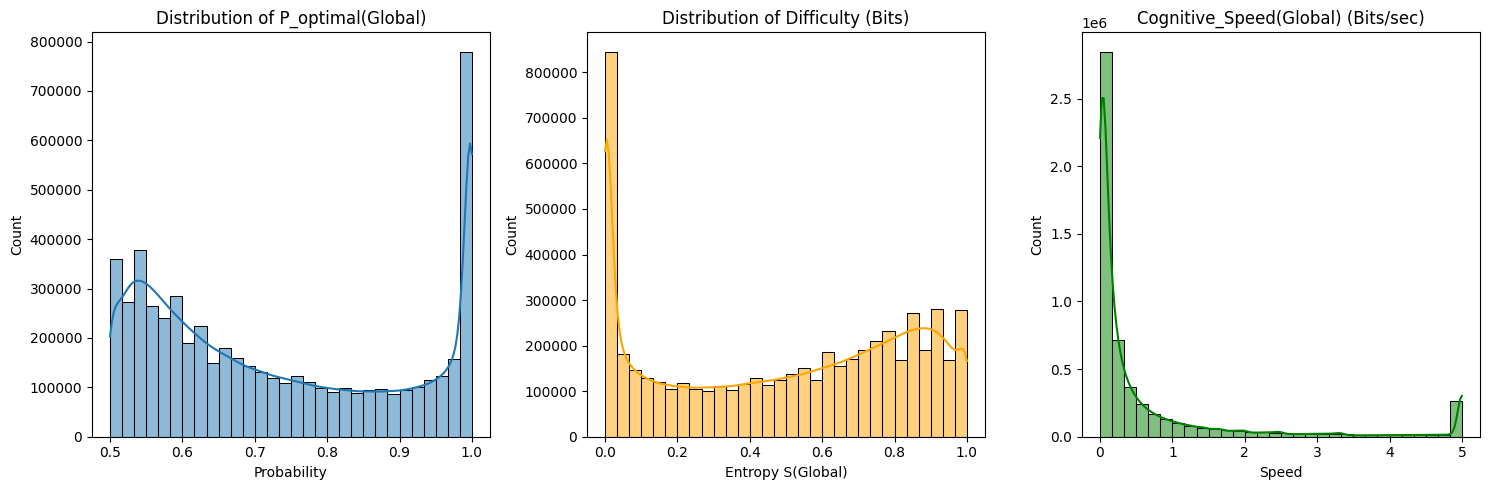

In [36]:
plt.figure(figsize=(15, 5))
# P distribution
plt.subplot(1, 3, 1)
sns.histplot(complex_drop_opening['P_optimal(Global)'], bins=30, kde=True)
plt.title('Distribution of P_optimal(Global)')
plt.xlabel('Probability')
# S distribution
plt.subplot(1, 3, 2)
sns.histplot(complex_drop_opening['S(Global)'], bins=30, kde=True, color='orange')
plt.title('Distribution of Difficulty (Bits)')
plt.xlabel('Entropy S(Global)')
# Cognitive distribution
plt.subplot(1, 3, 3)
# 截断一下长尾，看主体分布
sns.histplot(complex_drop_opening['Cognitive_Speed(Global)'].clip(upper=5), bins=30, kde=True, color='green')
plt.title('Cognitive_Speed(Global) (Bits/sec)')
plt.xlabel('Speed')

plt.tight_layout()
plt.show()

In [37]:
complex_drop_opening.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,P_optimal(Global),S(Global),Cognitive_Speed(Global),Game_Length,Progress
6,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,0.593873,0.751773,0.268491,61,0.213115
7,14,34,15,Dennis Wagner,White,58,70,55,29,28,27,-,0,0,12.0,31.0,2802,2800-3000,0,0,175.7,Rich (>170),0.3,0.650219,0.621003,2.070011,61,0.245902
8,15,34,16,Petar Ratkovic,Black,80,58,69,72,81,90,-,0,0,22.0,16.0,2463,2400-2600,0,0,179.8,Rich (>170),0.8,0.579324,0.787557,0.984446,61,0.262295
9,16,34,17,Dennis Wagner,White,85,80,74,73,63,53,-,0,0,-5.0,11.0,2802,2800-3000,0,1,175.4,Rich (>170),6.5,0.554779,0.850014,0.130771,61,0.278689
10,17,34,18,Petar Ratkovic,Black,122,85,99,101,101,107,-,0,0,37.0,16.0,2463,2400-2600,0,0,179.0,Rich (>170),0.3,0.579324,0.787557,2.625190,61,0.295082


In [38]:
# 1. 准备工作：定义分组阈值字典
delta0_map = {
    '>=3000': 105.3,
    '2800-3000': 113.3,
    '2600-2800': 118.5,
    '2400-2600': 122.5,
    '2200-2400': 138.3,
    '2000-2200': 129.8,
    '<2000': 140.0,     # 手动补全
    'Unknown': 120.0    # 默认值
}

# 2. 关键步骤：利用 map 生成一列对齐的 Delta0
# 这行代码会瞬间给几百万行数据填上对应的 Delta0
complex_drop_opening['Delta0_Group'] = complex_drop_opening['ELO_Group'].map(delta0_map)

# 处理一下 map 之后可能产生的 NaN (如果有漏掉的组)，填充为默认值 100
complex_drop_opening['Delta0_Group'] = complex_drop_opening['Delta0_Group'].fillna(100.0)

print("Delta0 分组列生成完毕！预览：")
print(complex_drop_opening[['ELO_Group', 'Delta0_Group']].head())

# --- 开始向量化计算 ---

# 1. 计算 P (Group specific)
# 公式： 1 / (1 + exp(-Δ / Δ0_group))
delta_values = complex_drop_opening['Δ'].values
d0_values = complex_drop_opening['Delta0_Group'].values  # 取出这一列作为分母数组

# 同样使用 numpy 向量运算
p_values_group = 1 / (1 + np.exp(-delta_values / d0_values))

# 赋值 (不带 Global 后缀)
complex_drop_opening['P_optimal'] = p_values_group

# 2. 计算 S (Group specific)
# 同样处理 P接近0 的情况
complex_drop_opening['S'] = np.where(
    p_values_group > 1e-9, 
    -np.log2(p_values_group), 
    1.0
)

# 3. 计算 S/t (Group specific)
# 处理时间为 0 的情况
safe_time = complex_drop_opening['Move_Time'].replace(0, 0.1) 
complex_drop_opening['Cognitive_Speed'] = complex_drop_opening['S'] / safe_time

print("分组指标 (P_optimal, S, Cognitive_Speed) 计算完成！")

Delta0 分组列生成完毕！预览：
    ELO_Group  Delta0_Group
6   2800-3000         113.3
7   2800-3000         113.3
8   2400-2600         122.5
9   2800-3000         113.3
10  2400-2600         122.5
分组指标 (P_optimal, S, Cognitive_Speed) 计算完成！


In [39]:
time_complex.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,P_optimal(Global),S(Global),Cognitive_Speed(Global),Game_Length,Progress
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,0.534943,0.902543,0.694264,61,0.016393
1,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,0.685680,0.544392,1.360981,61,0.065574
2,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,0.579324,0.787557,7.875570,61,0.081967
3,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,0.617748,0.694910,6.949100,61,0.098361
4,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,0.603483,0.728614,3.643072,61,0.147541


In [40]:
complex_drop_opening.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,P_optimal(Global),S(Global),Cognitive_Speed(Global),Game_Length,Progress,Delta0_Group,P_optimal,S,Cognitive_Speed
6,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,0.593873,0.751773,0.268491,61,0.213115,113.3,0.541826,0.884098,0.315749
7,14,34,15,Dennis Wagner,White,58,70,55,29,28,27,-,0,0,12.0,31.0,2802,2800-3000,0,0,175.7,Rich (>170),0.3,0.650219,0.621003,2.070011,61,0.245902,113.3,0.567979,0.816091,2.720302
8,15,34,16,Petar Ratkovic,Black,80,58,69,72,81,90,-,0,0,22.0,16.0,2463,2400-2600,0,0,179.8,Rich (>170),0.8,0.579324,0.787557,0.984446,61,0.262295,122.5,0.532607,0.908857,1.136072
9,16,34,17,Dennis Wagner,White,85,80,74,73,63,53,-,0,0,-5.0,11.0,2802,2800-3000,0,1,175.4,Rich (>170),6.5,0.554779,0.850014,0.130771,61,0.278689,113.3,0.524253,0.931665,0.143333
10,17,34,18,Petar Ratkovic,Black,122,85,99,101,101,107,-,0,0,37.0,16.0,2463,2400-2600,0,0,179.0,Rich (>170),0.3,0.579324,0.787557,2.625190,61,0.295082,122.5,0.532607,0.908857,3.029525


In [41]:
complex_drop_opening.columns

Index(['Unnamed: 0', 'uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2',
       'E3', 'E4', 'E5', 'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ',
       'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal', 'Remain_Time',
       'Time_Group', 'Move_Time', 'P_optimal(Global)', 'S(Global)',
       'Cognitive_Speed(Global)', 'Game_Length', 'Progress', 'Delta0_Group',
       'P_optimal', 'S', 'Cognitive_Speed'],
      dtype='object')

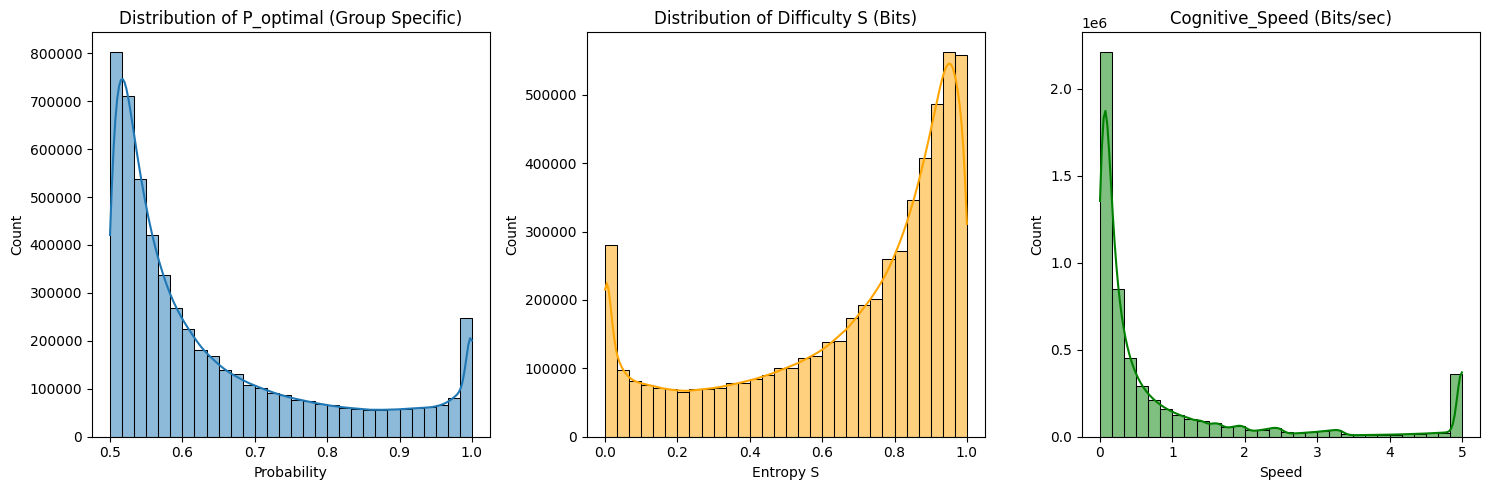

In [42]:
# 过滤数据用于画图 (去掉开局和强制步)
plt.figure(figsize=(15, 5))

# 图1: P distribution (Group Specific)
plt.subplot(1, 3, 1)
sns.histplot(complex_drop_opening['P_optimal'], bins=30, kde=True)
plt.title('Distribution of P_optimal (Group Specific)')
plt.xlabel('Probability')

# 图2: S distribution (Group Specific)
plt.subplot(1, 3, 2)
sns.histplot(complex_drop_opening['S'], bins=30, kde=True, color='orange')
plt.title('Distribution of Difficulty S (Bits)')
plt.xlabel('Entropy S')

# 图3: Cognitive Speed distribution (Group Specific)
plt.subplot(1, 3, 3)
sns.histplot(complex_drop_opening['Cognitive_Speed'].clip(upper=5), bins=30, kde=True, color='green')
plt.title('Cognitive_Speed (Bits/sec)')
plt.xlabel('Speed')

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30556\1391217953.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30556\1391217953.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']


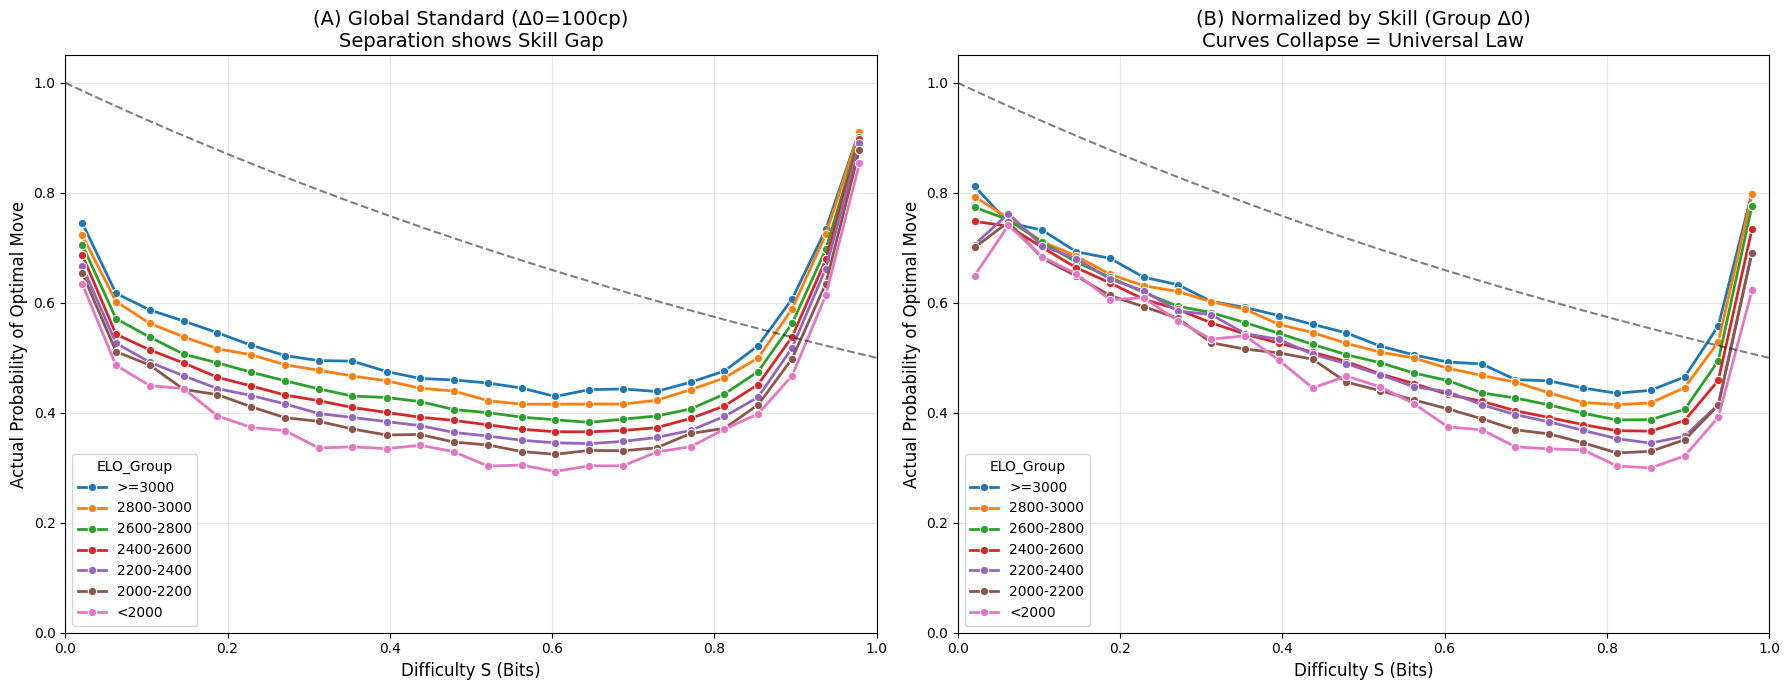

In [43]:
elo_order=['>=3000', '2800-3000', '2600-2800',
               '2400-2600', '2200-2400', '2000-2200', '<2000']
# 画S（Global和非Global）和P_Optimal的关系
def plot_difficulty_curve(data, x_col, title, ax):
    # 1. 分桶：把 S 切分成 20 个小区间 (0 到 1.0)
    # 使用 pd.cut 把连续的 S 变成区间
    data['S_Bin'] = pd.cut(data[x_col], bins=np.linspace(0, 1.0, 25))
    
    # 2. 聚合：计算每个区间、每个组的 实际准确率 (Is_Optimal)
    agg_data = (
        data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
        .mean()
        .reset_index()
        .rename(columns={'Is_Optimal': 'Actual_Win_Rate'})
    )
    
    # 3. 处理 X 轴：把区间 (0.1, 0.15] 变成中点 0.125 方便画图
    agg_data['S_Mid'] = agg_data['S_Bin'].apply(lambda x: x.mid)
    
    # 4. 画线
    sns.lineplot(
        data=agg_data, 
        x='S_Mid', 
        y='Actual_Win_Rate', 
        hue='ELO_Group', 
        hue_order=elo_order,
        marker='o',
        linewidth=2,
        ax=ax
    )
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Difficulty S (Bits)', fontsize=12)
    ax.set_ylabel('Actual Probability of Optimal Move', fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 1.0)
    ax.grid(True, alpha=0.3)
    # 添加对角线参考 (理论预测)
    # 理论上 P = 2^(-S)，可以画一条虚线对比实际值
    x_ref = np.linspace(0, 1, 100)
    y_ref = 2 ** (-x_ref)
    ax.plot(x_ref, y_ref, 'k--', alpha=0.5, label='Theoretical Model')


# --- 开始画图 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 图1：Global Standard (展示能力差距)
plot_difficulty_curve(
    complex_drop_opening.copy(), 
    x_col='S(Global)', 
    title='(A) Global Standard (Δ0=100cp)\nSeparation shows Skill Gap', 
    ax=axes[0]
)

# 图2：Group Specific (展示规律统一)
plot_difficulty_curve(
    complex_drop_opening.copy(), 
    x_col='S', 
    title='(B) Normalized by Skill (Group Δ0)\nCurves Collapse = Universal Law', 
    ax=axes[1]
)

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30556\2092682308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


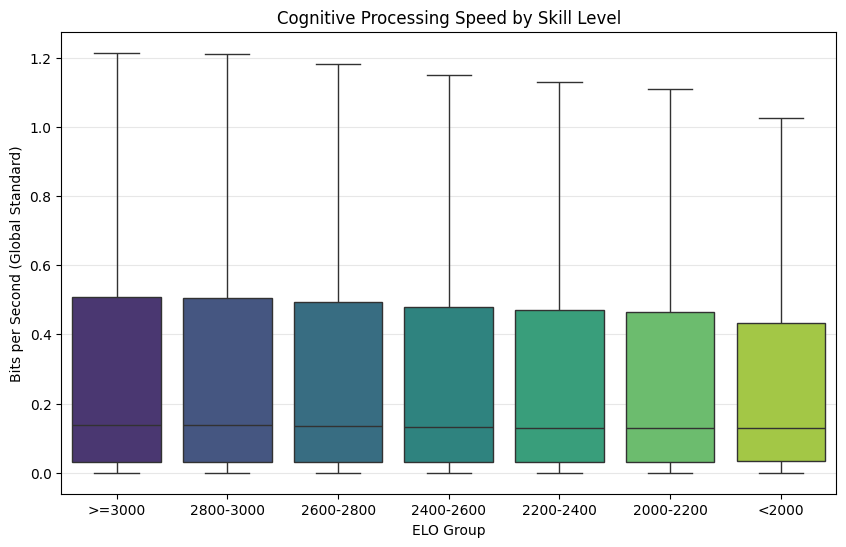

In [44]:
plt.figure(figsize=(10, 6))
# 过滤掉极端值以便观察
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed(Global)'] < 5].copy()
sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed(Global)',
    order=elo_order,
    palette='viridis',
    showfliers=False  # 不显示离群点，让箱体更清晰
)
plt.title('Cognitive Processing Speed by Skill Level')
plt.ylabel('Bits per Second (Global Standard)')
plt.xlabel('ELO Group')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30556\3130546923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


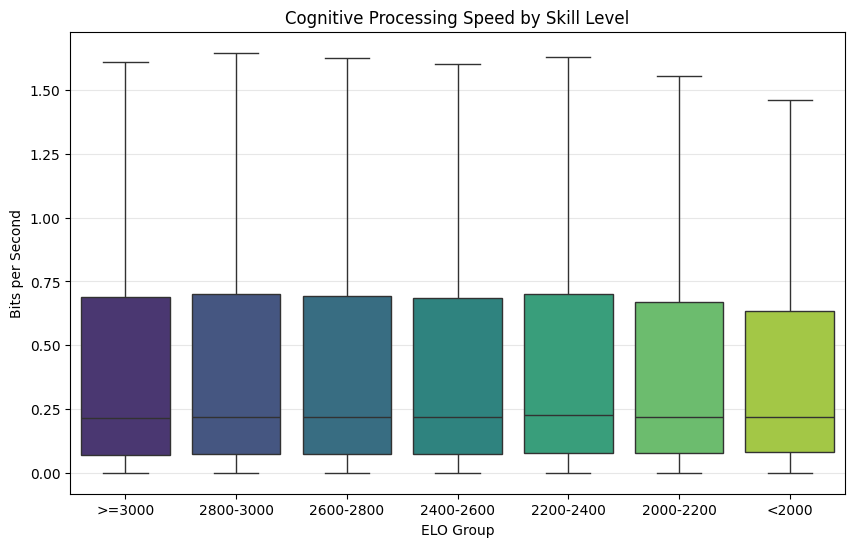

In [45]:
plt.figure(figsize=(10, 6))
# 过滤掉极端值以便观察
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed'] < 5].copy()
sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed',
    order=elo_order,
    palette='viridis',
    showfliers=False  # 不显示离群点，让箱体更清晰
)
plt.title('Cognitive Processing Speed by Skill Level')
plt.ylabel('Bits per Second')
plt.xlabel('ELO Group')
plt.grid(axis='y', alpha=0.3)
plt.show() 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_30556\3695305102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


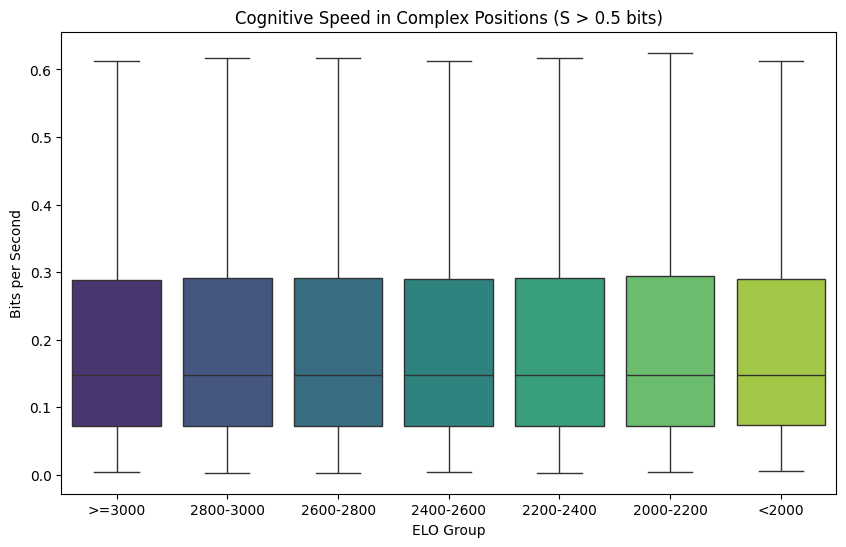

In [46]:
plt.figure(figsize=(10, 6))

# --- 关键修改：只看难题 ---
# 过滤 S(Global) > 0.5 的局面
# 意思是：只看那些真正需要动脑子的棋，这时候谁脑子快一目了然
difficult_moves = complex_drop_opening[
    (complex_drop_opening['S(Global)'] > 0.4) & 
    (complex_drop_opening['S(Global)'] < 0.9) &
    (complex_drop_opening['Cognitive_Speed(Global)'] < 5) &
    (complex_drop_opening['Move_Time'] > 1.0)
].copy()

sns.boxplot(
    data=difficult_moves,
    x='ELO_Group',
    y='Cognitive_Speed(Global)',
    order=elo_order,
    palette='viridis',
    showfliers=False
)

plt.title('Cognitive Speed in Complex Positions (S > 0.5 bits)') # 标题改一下
plt.ylabel('Bits per Second')
plt.xlabel('ELO Group')
plt.show()

棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [47]:
pd.set_option('display.max_columns', None)
complex_drop_opening.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,P_optimal(Global),S(Global),Cognitive_Speed(Global),Game_Length,Progress,Delta0_Group,P_optimal,S,Cognitive_Speed
6,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,0.593873,0.751773,0.268491,61,0.213115,113.3,0.541826,0.884098,0.315749
7,14,34,15,Dennis Wagner,White,58,70,55,29,28,27,-,0,0,12.0,31.0,2802,2800-3000,0,0,175.7,Rich (>170),0.3,0.650219,0.621003,2.070011,61,0.245902,113.3,0.567979,0.816091,2.720302
8,15,34,16,Petar Ratkovic,Black,80,58,69,72,81,90,-,0,0,22.0,16.0,2463,2400-2600,0,0,179.8,Rich (>170),0.8,0.579324,0.787557,0.984446,61,0.262295,122.5,0.532607,0.908857,1.136072
9,16,34,17,Dennis Wagner,White,85,80,74,73,63,53,-,0,0,-5.0,11.0,2802,2800-3000,0,1,175.4,Rich (>170),6.5,0.554779,0.850014,0.130771,61,0.278689,113.3,0.524253,0.931665,0.143333
10,17,34,18,Petar Ratkovic,Black,122,85,99,101,101,107,-,0,0,37.0,16.0,2463,2400-2600,0,0,179.0,Rich (>170),0.3,0.579324,0.787557,2.625190,61,0.295082,122.5,0.532607,0.908857,3.029525


=== Mistake / Blunder 's S distribution 每个区间步数 ===
0.000-0.020: 232169            | 0.020-0.040: 71095
0.040-0.060: 57769             | 0.060-0.080: 50405
0.080-0.100: 47486             | 0.100-0.120: 45929
0.120-0.140: 45180             | 0.140-0.160: 42934
0.160-0.180: 41158             | 0.180-0.200: 41649
0.200-0.220: 40448             | 0.220-0.240: 39714
0.240-0.260: 41177             | 0.260-0.280: 41361
0.280-0.300: 42269             | 0.300-0.320: 43156
0.320-0.340: 42494             | 0.340-0.360: 47362
0.360-0.380: 48085             | 0.380-0.400: 47584
0.400-0.420: 51143             | 0.420-0.440: 50714
0.440-0.460: 55268             | 0.460-0.480: 56298
0.480-0.500: 61312             | 0.500-0.520: 59148
0.520-0.540: 63859             | 0.540-0.560: 65737
0.560-0.580: 69440             | 0.580-0.600: 74266
0.600-0.620: 78570             | 0.620-0.640: 82511
0.640-0.660: 94431             | 0.660-0.680: 87372
0.680-0.700: 109386            | 0.700-0.720: 107087
0.720-0.740:

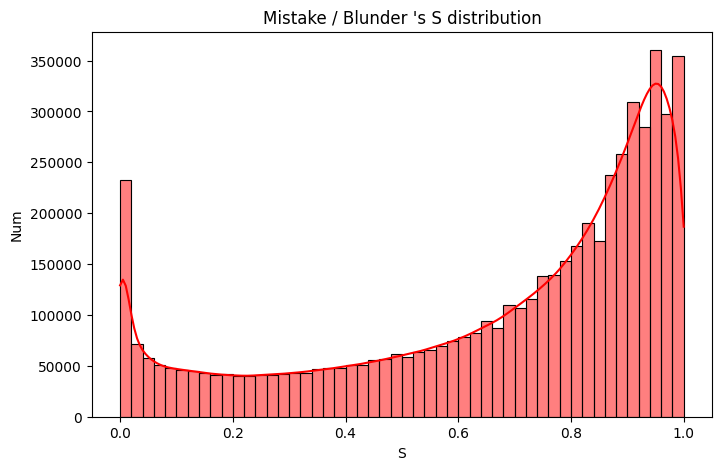

In [48]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='S', bins=50, kde=True, title="Mistake / Blunder 's S distribution", xlabel='S', ylabel='Num',color='red')

=== Mistake / Blunder 's Game-Progress distribution 每个区间步数 ===
0.201-0.217: 111641            | 0.217-0.233: 118389
0.233-0.249: 117580            | 0.249-0.265: 119300
0.265-0.281: 120275            | 0.281-0.297: 120733
0.297-0.313: 123689            | 0.313-0.329: 118957
0.329-0.345: 121258            | 0.345-0.361: 121539
0.361-0.376: 120452            | 0.376-0.392: 121507
0.392-0.408: 121210            | 0.408-0.424: 118987
0.424-0.440: 119049            | 0.440-0.456: 119091
0.456-0.472: 118224            | 0.472-0.488: 118230
0.488-0.504: 112377            | 0.504-0.520: 119586
0.520-0.536: 115560            | 0.536-0.552: 114821
0.552-0.568: 113020            | 0.568-0.584: 112337
0.584-0.600: 118502            | 0.600-0.616: 104564
0.616-0.632: 109218            | 0.632-0.648: 109404
0.648-0.664: 108823            | 0.664-0.680: 105836
0.680-0.696: 105862            | 0.696-0.712: 104473
0.712-0.728: 102917            | 0.728-0.744: 103860
0.744-0.760: 100986            | 0.7

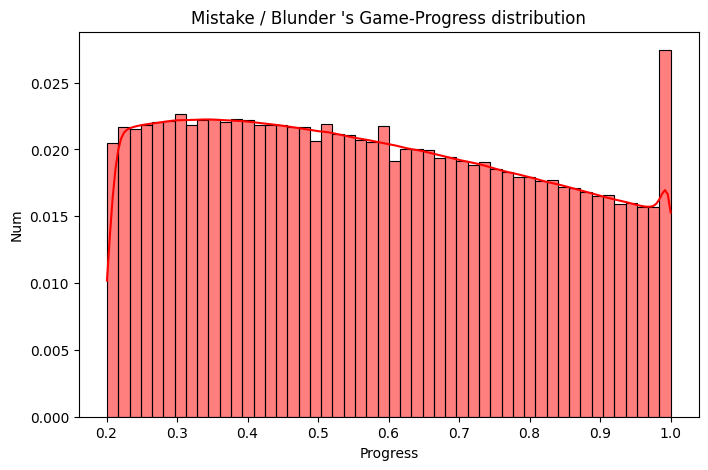

In [55]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color, stat='probability')
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='Progress', bins=50, kde=True, title="Mistake / Blunder 's Game-Progress distribution", xlabel='Progress', ylabel='Num',color='red')

=== Mistake / Blunder 's S(Global) distribution 每个区间步数 ===
0.000-0.020: 742828            | 0.020-0.040: 143772
0.040-0.060: 110923            | 0.060-0.080: 88459
0.080-0.100: 87023             | 0.100-0.120: 74333
0.120-0.140: 72552             | 0.140-0.160: 69580
0.160-0.180: 76615             | 0.180-0.200: 59483
0.200-0.220: 63525             | 0.220-0.240: 69021
0.240-0.260: 58754             | 0.260-0.280: 63415
0.280-0.300: 67828             | 0.300-0.320: 72655
0.320-0.340: 58363             | 0.340-0.360: 61843
0.360-0.380: 88553             | 0.380-0.400: 47726
0.400-0.420: 75351             | 0.420-0.440: 80674
0.440-0.460: 85623             | 0.460-0.480: 60378
0.480-0.500: 63541             | 0.500-0.520: 101606
0.520-0.540: 71509             | 0.540-0.560: 75109
0.560-0.580: 80231             | 0.580-0.600: 85006
0.600-0.620: 90626             | 0.620-0.640: 95359
0.640-0.660: 101253            | 0.660-0.680: 108195
0.680-0.700: 116019            | 0.700-0.720: 124117
0

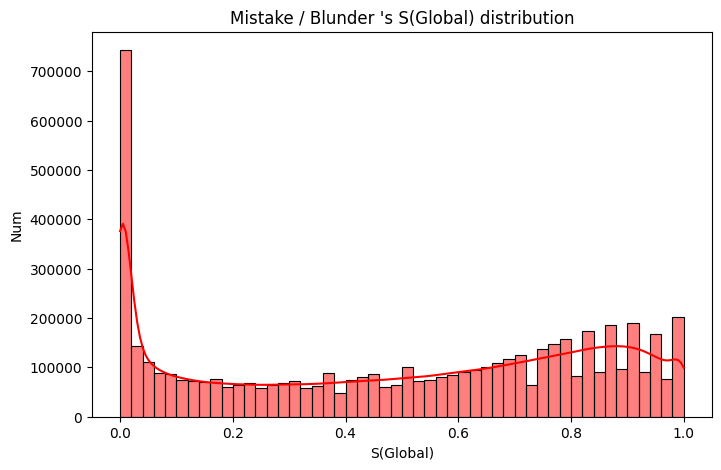

In [49]:
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Count', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color)
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show()
#mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=complex_drop_opening, col='S(Global)', bins=50, kde=True, title="Mistake / Blunder 's S(Global) distribution", xlabel='S(Global)', ylabel='Num',color='red')

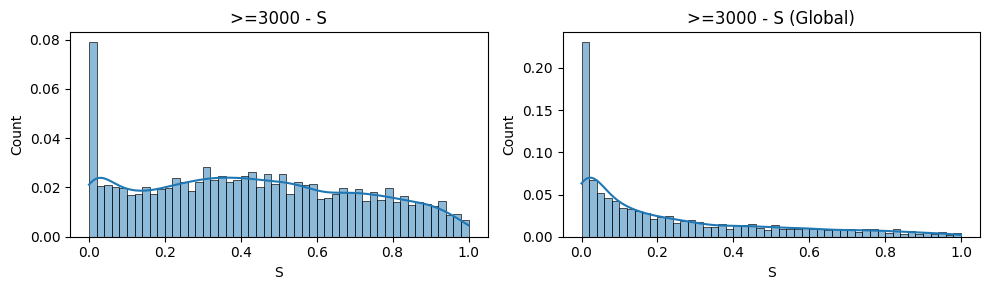

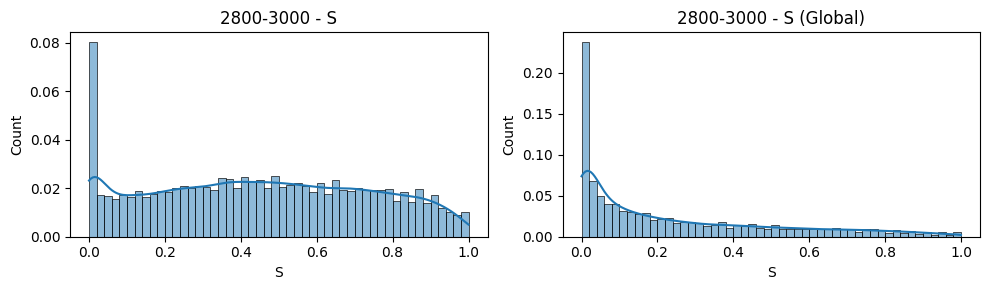

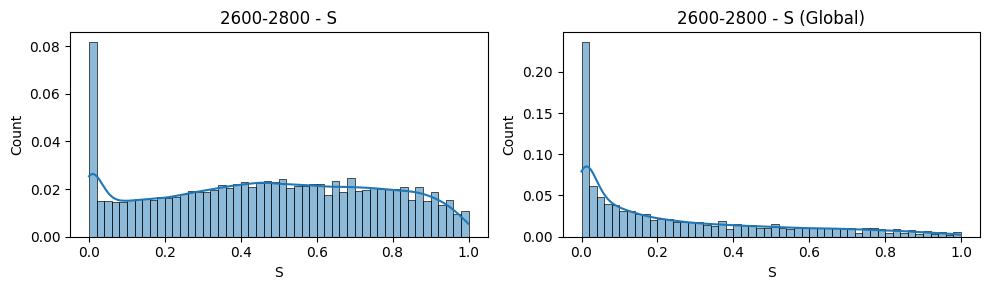

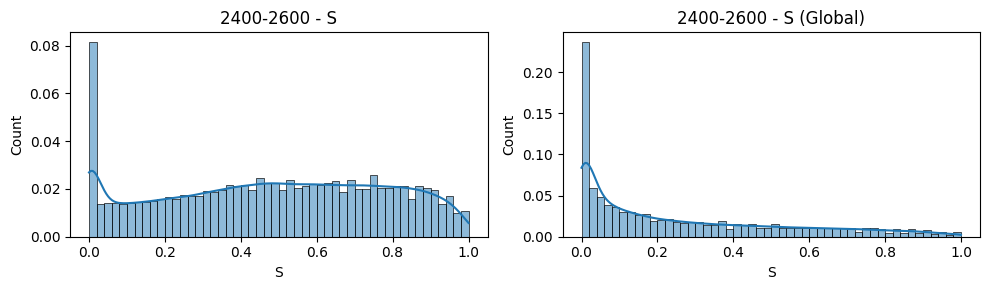

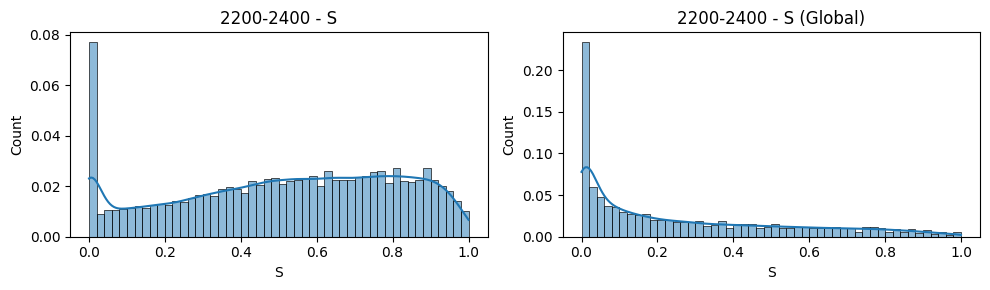

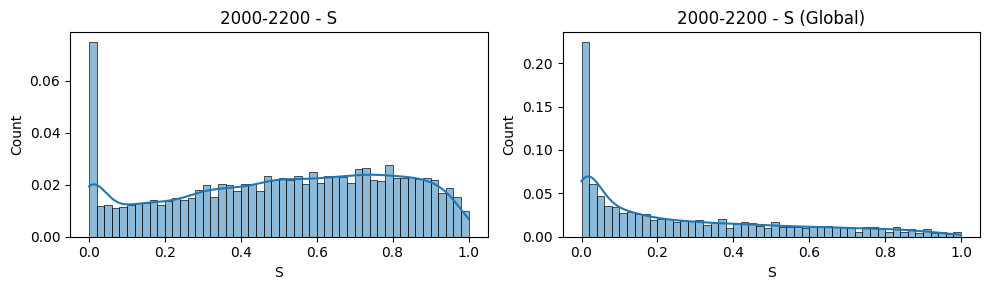

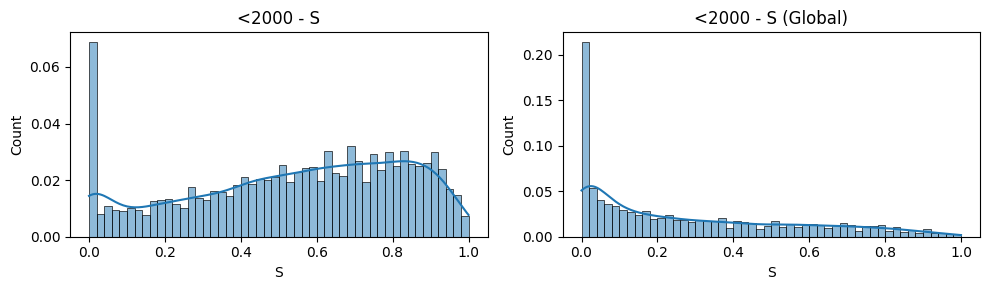

In [ ]:
def plot_hist_compare_by_elo(df, elo_order, bins=50, kde=True):
    for elo in elo_order:
        sub_df = df[df['ELO_Group'] == elo]

        values_local = sub_df['S'].dropna()
        values_global = sub_df['S(Global)'].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        # 左图：Group-specific S
        sns.histplot(values_local, bins=bins, kde=kde, ax=axes[0], stat='probability')
        axes[0].set_title(f"{elo} - S")
        axes[0].set_xlabel("S")
        axes[0].set_ylabel("Count")

        # 右图：Global S
        sns.histplot(values_global, bins=bins, kde=kde, ax=axes[1], stat='probability')
        axes[1].set_title(f"{elo} - S (Global)")
        axes[1].set_xlabel("S")
        axes[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()

plot_hist_compare_by_elo(
    df=errors_df,
    elo_order=elo_order,
    bins=50,
    kde=True
)


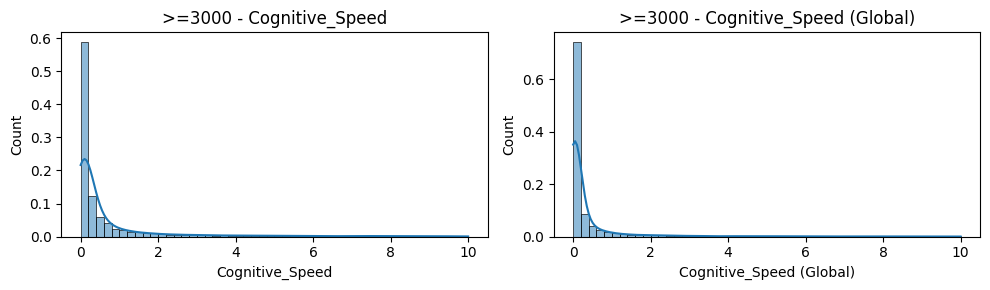

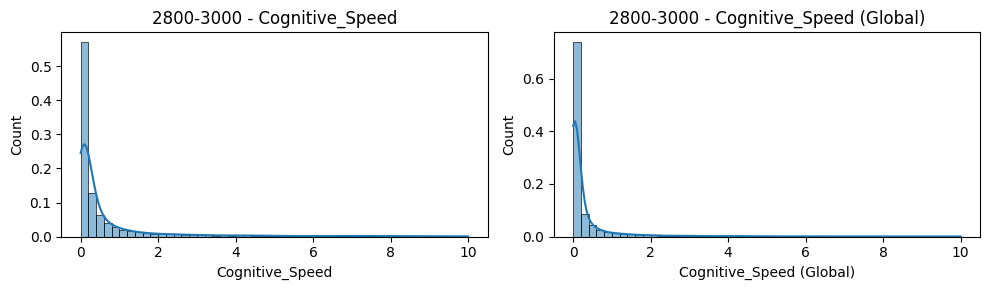

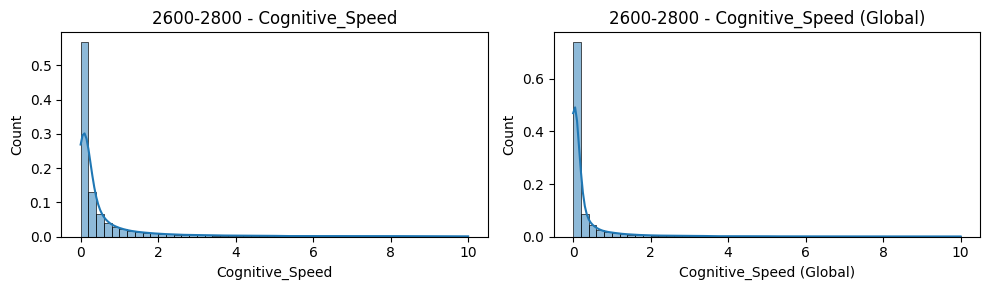

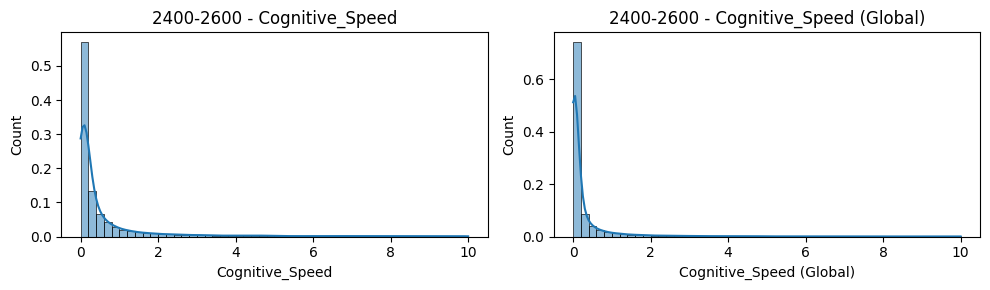

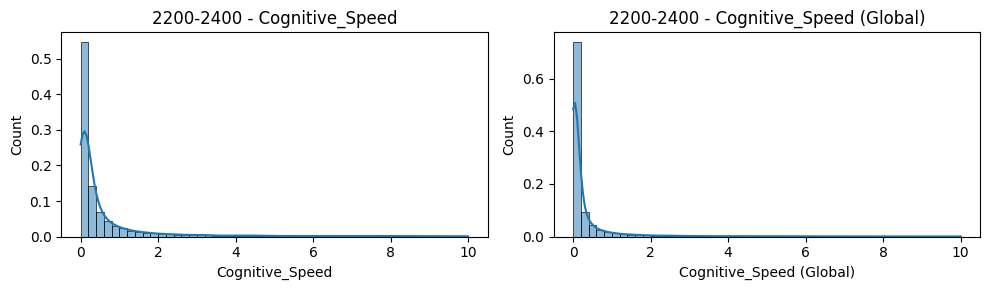

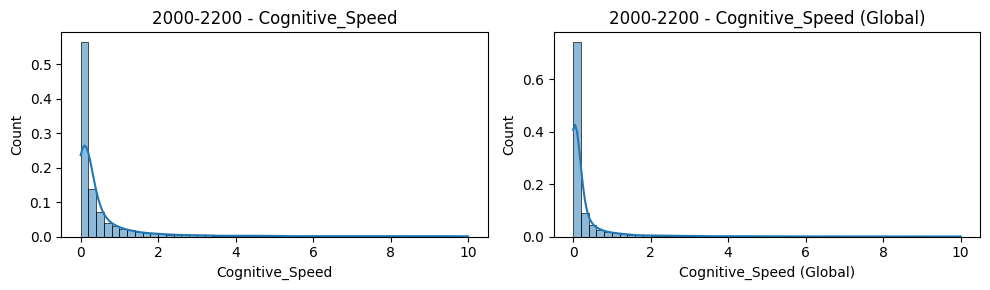

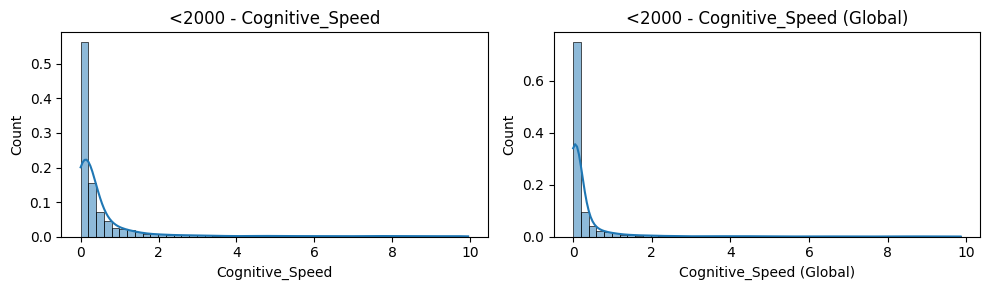

In [51]:
def plot_hist_compare_by_elo(df, elo_order, bins=50, kde=True):
    for elo in elo_order:
        sub_df = df[df['ELO_Group'] == elo]

        values_local = sub_df['Cognitive_Speed'].dropna()
        values_global = sub_df['Cognitive_Speed(Global)'].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        # 左图：Group-specific Cognitive_Speed
        sns.histplot(values_local, bins=bins, kde=kde, ax=axes[0], stat='probability',)
        axes[0].set_title(f"{elo} - Cognitive_Speed")
        axes[0].set_xlabel("Cognitive_Speed")
        axes[0].set_ylabel("Count")

        # 右图：Global Cognitive_Speed
        sns.histplot(values_global, bins=bins, kde=kde, ax=axes[1], stat='probability',)
        axes[1].set_title(f"{elo} - Cognitive_Speed (Global)")
        axes[1].set_xlabel("Cognitive_Speed (Global)")
        axes[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()

plot_hist_compare_by_elo(
    df=errors_df,
    elo_order=elo_order,
    bins=50,
    kde=True
)